## Add feature *size_kw*  and *state* to model

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

In [2]:
# Import sklearn stuff

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline,  make_pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
# read cleaned data
dfModelAll = pd.read_csv('../local/data/LBNL_openpv_tts_data/ModelAll.csv', index_col='row', dtype={'state':'category'})

In [4]:
dfModelAll.head()

,num_days,size_kw,state,cost_per_watt,scaleSize
row,,,,,
0,0.0,2.2824,CA,10.734315,0
1,21.0,1.8504,CA,11.108701,0
2,26.0,2.3076,CA,8.667013,0
3,84.0,2.3316,CA,13.270286,0
4,111.0,0.9300,CA,14.654839,0


In [5]:
dfModelAll.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 364212 entries, 0 to 364211
Data columns (total 5 columns):
num_days         364212 non-null float64
size_kw          364212 non-null float64
state            364212 non-null category
cost_per_watt    364212 non-null float64
scaleSize        364212 non-null int64
dtypes: category(1), float64(3), int64(1)
memory usage: 14.2 MB


In [6]:
dfModelAll.state.unique()

[CA, OR, AZ, NY, MN, ..., MD, CT, FL, NM, AR]
Length: 19
Categories (19, object): [CA, OR, AZ, NY, ..., CT, FL, NM, AR]

##### I have a choice to deal with encoding of categorical variable 'state' with pandas or in the pipeline.  I don't want to make polynomial terms for the state.

### make a small dataset to try out the pipeline

#### let's do the one hot encoding with pandas

In [67]:
dfMod = dfModelAll.sample(frac=1.0); dfMod.head()

,num_days,size_kw,state,cost_per_watt,scaleSize
row,,,,,
346517,6870.0,4.200,NY,5.520476,1
120567,5086.0,7.068,CA,6.354032,2
350556,6884.0,8.750,TX,3.997714,3
186232,6011.0,9.540,NY,4.480084,3
183114,5969.0,6.750,MA,4.811852,2


In [68]:
dfMod = pd.get_dummies(dfMod, drop_first=True)

In [69]:
dfMod.head()

,num_days,size_kw,cost_per_watt,scaleSize,state_AZ,state_CA,state_CT,state_DE,state_FL,state_MA,state_MD,state_MN,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OR,state_PA,state_TX,state_VT,state_WI
row,,,,,,,,,,,,,,,,,,,,,,
346517,6870.0,4.200,5.520476,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
120567,5086.0,7.068,6.354032,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
350556,6884.0,8.750,3.997714,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
186232,6011.0,9.540,4.480084,3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
183114,5969.0,6.750,4.811852,2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


#### State is coded one-hot now, but how to do the polynomial transform in pipeline without including dummy vars?

It seems like I want a FeatureUnion to do polynomial expansion on num_days, size_kw, on one side and do nothing to the state_AZ, etc.

In [10]:
theCols = dfMod1k.columns; theCols

Index(['num_days', 'size_kw', 'cost_per_watt', 'scaleSize', 'state_AZ',
       'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA', 'state_MD',
       'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY',
       'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI'],
      dtype='object')

#### Note: FeatureUnion transformation returns np.ndarray

#### Prep data for sklearn 

In [11]:
# for now work with small set
X1k = dfMod1k.drop(['cost_per_watt', 'scaleSize'], axis='columns')
y1k = dfMod1k[['cost_per_watt']]
X1k.shape, y1k.shape

((1000, 20), (1000, 1))

In [12]:
# take a look to make sure it's right.
X1k[:3]

,num_days,size_kw,state_AZ,state_CA,state_CT,state_DE,state_FL,state_MA,state_MD,state_MN,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OR,state_PA,state_TX,state_VT,state_WI
row,,,,,,,,,,,,,,,,,,,,
110732,4959.0,6.88,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
348037,6874.0,2.48,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
266658,6584.0,8.50,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [13]:
theStates = ['state_AZ', 'state_CA', 'state_CT', 'state_DE', 'state_FL', 'state_MA', 'state_MD',
            'state_MN', 'state_NH', 'state_NJ', 'state_NM', 'state_NV', 'state_NY',
            'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI']

### Build a pipeline that does the right thing

* Take the data apart into numerical and dummy vars encoding $State$.
    * Numerical variables
        * scale
        * polynomial transform
    * Dummy variables
        * pass through
* Put poly transform back together with dummy variable for the regression

#### Make a transformer that can grab specified columns.

In [14]:
### make it an estimator and a transformer for general use
class ColumnExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None):
        self.columns = columns
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X_cols = X[self.columns]
        return X_cols

# this didn't solve my problem; actually caused a different problem
#     def fit_transform(self, X, y=None):
#         return transform(fit(self, X, y), X)
# maybe need to take this arg list self, X, y, **fit_params       

#### test ColumnExtractor

In [15]:
extractNumerical = ColumnExtractor(columns=['num_days', 'size_kw'])
extractNumerical.fit_transform(dfMod1k.head(3))            

,num_days,size_kw
row,,
110732,4959.0,6.88
348037,6874.0,2.48
266658,6584.0,8.50


In [16]:
extractDummies = ColumnExtractor(columns=theStates)
extractDummies.fit_transform(dfMod1k.head(3))            

,state_AZ,state_CA,state_CT,state_DE,state_FL,state_MA,state_MD,state_MN,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OR,state_PA,state_TX,state_VT,state_WI
row,,,,,,,,,,,,,,,,,,
110732,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
348037,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
266658,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


In [17]:
# take the data apart; numerical vars get scaled, then go to polynomial; state dummies pass through; 
# they get glued back together for the regression.
testPipe = Pipeline([
    ('features', 
     FeatureUnion([('num_vars', 
                    Pipeline([('extract', ColumnExtractor(columns=['num_days', 'size_kw'])) ,
                              ('scale', StandardScaler()),
                              ('poly', PolynomialFeatures())
                              ])),
                   ('cat_vars',
                    ColumnExtractor(columns=theStates))
                  ]) # end of FeatureUnion
    )]) # end of Pipeline

#### Test pipe without the regression

#### First make sure of the name of the parameter I want to use

In [18]:
testPipe.get_params()['features__num_vars__poly__degree']

2

In [19]:
testPipe.set_params(features__num_vars__poly__degree=1)

Pipeline(memory=None,
     steps=[('features', FeatureUnion(n_jobs=1,
       transformer_list=[('num_vars', Pipeline(memory=None,
     steps=[('extract', ColumnExtractor(columns=['num_days', 'size_kw'])), ('scale', StandardScaler(copy=True, with_mean=True, with_std=True)), ('poly', PolynomialFeatures(degree=1, include_bias=True, interaction_only=False))])), ('cat_vars', Colu..., 'state_NM', 'state_NV', 'state_NY', 'state_OR', 'state_PA', 'state_TX', 'state_VT', 'state_WI']))],
       transformer_weights=None))])

In [20]:
testPipe.get_params()['features__num_vars__poly__degree']

1

In [21]:
testPipe.fit_transform(dfMod1k.head(3))

array([[ 1.    , -1.4002,  0.3643,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  1.    ,  0.    ,  0.    ,  0.    ],
       [ 1.    ,  0.8722, -1.3656,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  1.    ,  0.    ,  0.    ],
       [ 1.    ,  0.528 ,  1.0012,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ,
         0.    ,  1.    ,  0.    ,  0.    ,  0.    ,  0.    ,  0.    ]])

#### Okay, looks like this pipeline does what it should.  Now add the regression as the last step and grid_search_CV on the small dataset.

In [26]:
# first, add LR to the pipeline
# take the data apart; numerical vars get scaled, then go to polynomial; state dummies pass through; 
# they get glued back together for the regression.
thePipe = Pipeline([
    ('features', 
     FeatureUnion([('num_vars', 
                    Pipeline([('extract', ColumnExtractor(columns=['num_days', 'size_kw'])) ,
                              ('scale', StandardScaler()),
                              ('poly', PolynomialFeatures())
                              ])),
                   ('cat_vars',
                    ColumnExtractor(columns=theStates))
                  ]) # end of FeatureUnion
    ),
    ('LR', LinearRegression())
]) # end of Pipeline

In [60]:
# Specify the hyperparameter space.
poly_space = np.arange(1, 11)
# Create the hyperparameter grid, just poly degree up to 6th
param_grid = {'features__num_vars__poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X33p, y33p, test_size=0.25, random_state=42)

# Create the GridSearchCV object: gm_cv
gs_cv = GridSearchCV(thePipe, param_grid, cv=3, return_train_score=True)

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(r2))

Best parameters: {'features__num_vars__poly__degree': 10}
test R squared: 0.5319205773360227


In [61]:
# this will show the results data structure
gs_cv.cv_results_

{'mean_fit_time': array([0.0749, 0.0805, 0.0939, 0.129 , 0.1601, 0.2082, 0.2517, 0.3219,
        0.3797, 0.4669]),
 'mean_score_time': array([0.0094, 0.0107, 0.013 , 0.0197, 0.0267, 0.0398, 0.0531, 0.0699,
        0.0946, 0.1183]),
 'mean_test_score': array([0.4575, 0.4807, 0.4986, 0.5119, 0.5137, 0.5237, 0.5247, 0.5273,
        0.5271, 0.528 ]),
 'mean_train_score': array([0.458 , 0.4812, 0.4993, 0.5127, 0.5148, 0.5252, 0.5264, 0.529 ,
        0.5296, 0.5304]),
 'param_features__num_vars__poly__degree': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'params': [{'features__num_vars__poly__degree': 1},
  {'features__num_vars__poly__degree': 2},
  {'features__num_vars__poly__degree': 3},
  {'features__num_vars__poly__degree': 4},
  {'features__num_vars__poly__degree': 5},
  {'features__num_vars__poly__degree': 6},
  {'feat

#### The pipeline above is working.  Try with 1/3 of the data.

#### Prep dataset


In [29]:
# grab random 1/3; 121k rows
dfMod33p = dfModelAll.sample(frac=0.333)
dfMod33p = pd.get_dummies(dfMod33p, drop_first=True)
X33p = dfMod33p.drop(['cost_per_watt', 'scaleSize'], axis='columns')
y33p = dfMod33p[['cost_per_watt']]
X33p.shape, y33p.shape

((121283, 20), (121283, 1))

In [70]:
# the whole thing
X = dfMod.drop(['cost_per_watt', 'scaleSize'], axis='columns')
y = dfMod[['cost_per_watt']]
X.shape, y.shape

((364212, 20), (364212, 1))

In [71]:
# Specify the hyperparameter space.
poly_space = np.arange(1, 13)
# Create the hyperparameter grid, poly degree up to 10th; this takes about a minute.
param_grid = {'features__num_vars__poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Create the GridSearchCV object: gm_cv
gs_cv = GridSearchCV(thePipe, param_grid, cv=3, return_train_score=True)

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(r2))

Best parameters: {'features__num_vars__poly__degree': 12}
test R squared: 0.5267764488302967


In [72]:
gs_cv.cv_results_

{'mean_fit_time': array([0.2259, 0.285 , 0.3279, 0.3974, 0.514 , 0.6571, 0.7891, 1.0093,
        1.2186, 1.5107, 1.8118, 2.141 ]),
 'mean_score_time': array([0.0277, 0.0338, 0.0578, 0.0632, 0.1006, 0.1317, 0.1898, 0.2363,
        0.3008, 0.3636, 0.4512, 0.5555]),
 'mean_test_score': array([0.46  , 0.4841, 0.5017, 0.515 , 0.517 , 0.5274, 0.5284, 0.5306,
        0.5311, 0.5318, 0.5319, 0.5327]),
 'mean_train_score': array([0.4602, 0.4843, 0.502 , 0.5153, 0.5174, 0.5277, 0.5289, 0.5312,
        0.5318, 0.5325, 0.5332, 0.5338]),
 'param_features__num_vars__poly__degree': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
              mask=[False, False, False, False, False, False, False, False,
                    False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'features__num_vars__poly__degree': 1},
  {'features__num_vars__poly__degree': 2},
  {'features__num_vars__poly__degree': 3},
  {'features__num_vars__poly__degree': 4},
  {'feat

(0.45, 0.55)

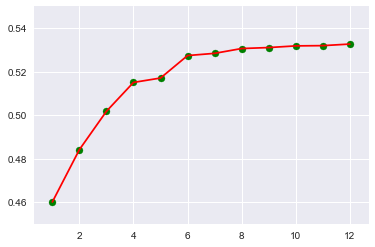

In [75]:
results=gs_cv.cv_results_
test_means = results['mean_test_score']
train_means = results['mean_test_score']
plt.plot(np.arange(1, len(test_means)+1), test_means, color='red')
plt.scatter(np.arange(1, len(test_means)+1),train_means,  marker='o',color='green')
plt.ylim(0.45, 0.55)

#### Now do multiple scoring so we can look at RMSE and $R^2$

In [77]:
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Specify the hyperparameter space.
poly_space = np.arange(1, 15)
# Create the hyperparameter grid, poly degree up to 10th
param_grid = {'features__num_vars__poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X33p, y33p, test_size=0.40, random_state=None)

# Create the GridSearchCV object: gs_cv
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

gs_cv = GridSearchCV(thePipe, param_grid, cv=3, 
                     scoring=scoring, return_train_score=True,
                     refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(r2))

# uncomment to see results ds
# gs_cv.cv_results_

Best parameters: {'features__num_vars__poly__degree': 11}
Best R squared: 0.5349152901661559


In [78]:
gs_cv.cv_results_

{'mean_fit_time': array([0.0508, 0.0568, 0.0759, 0.1031, 0.1247, 0.1638, 0.2035, 0.2443,
        0.3038, 0.371 , 0.4482, 0.5277, 0.6223, 0.7467]),
 'mean_score_time': array([0.014 , 0.0157, 0.0217, 0.0301, 0.0371, 0.0528, 0.0769, 0.1133,
        0.1464, 0.1892, 0.2436, 0.2848, 0.3563, 0.4544]),
 'mean_test_RMSE': array([-1.5944, -1.5583, -1.5316, -1.5109, -1.5077, -1.4936, -1.4923,
        -1.4861, -1.487 , -1.4875, -1.4856, -1.4899, -1.5455, -1.5792]),
 'mean_test_Rsquared': array([0.4534, 0.4779, 0.4956, 0.5092, 0.5112, 0.5203, 0.5212, 0.5251,
        0.5245, 0.5242, 0.5255, 0.5227, 0.4853, 0.4625]),
 'mean_train_RMSE': array([-1.5937, -1.5575, -1.5305, -1.5098, -1.5065, -1.4893, -1.4873,
        -1.483 , -1.4819, -1.4803, -1.4791, -1.4775, -1.4759, -1.4748]),
 'mean_train_Rsquared': array([0.4539, 0.4784, 0.4963, 0.5099, 0.5121, 0.5231, 0.5244, 0.5271,
        0.5279, 0.5289, 0.5296, 0.5306, 0.5316, 0.5323]),
 'param_features__num_vars__poly__degree': masked_array(data=[1, 2, 3, 4, 

(1.4780450513272376, 1.6019465402778694)

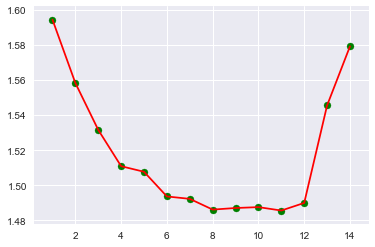

In [82]:
results=gs_cv.cv_results_
test_means = results['mean_test_RMSE']
train_means = results['mean_test_RMSE']
plt.plot(np.arange(1, len(test_means)+1), np.abs(test_means), color='red')
plt.scatter(np.arange(1, len(test_means)+1), np.abs(train_means),  marker='o',color='green')
plt.ylim()

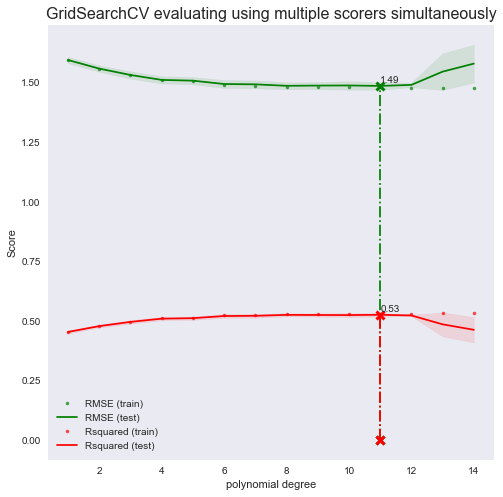

In [83]:
results = gs_cv.cv_results_

fig, ax = plt.subplots(figsize=(8, 8))
plt.title("GridSearchCV evaluating using multiple scorers simultaneously", fontsize=16)

plt.xlabel("polynomial degree")
plt.ylabel("Score")

# I think Seaborn ignores this...
plt.grid(True)

###            two__underscores
X_axis = np.array(results['param_features__num_vars__poly__degree'].data, dtype=float)

for scorer, color in zip(sorted(scoring), ['g', 'r']):
    for sample, style in (('train', '.'), ('test', '-')):
        sample_score_mean = np.abs(results['mean_%s_%s' % (sample, scorer)])
        sample_score_std = results['std_%s_%s' % (sample, scorer)]
        ax.fill_between(X_axis, sample_score_mean - sample_score_std,
                        sample_score_mean + sample_score_std,
                        alpha=0.1 if sample == 'test' else 0, color=color)
        ax.plot(X_axis, sample_score_mean, style, color=color,
                alpha=1 if sample == 'test' else 0.7,
                label="%s (%s)" % (scorer, sample))

    best_index = np.abs(np.nonzero(results['rank_test_%s' % scorer] == 1)[0][0])
    best_score = np.abs(results['mean_test_%s' % scorer][best_index])

    # Plot a dotted vertical line at the best score for that scorer marked by x
    ax.plot([X_axis[best_index], ] * 2, [0, best_score],
            linestyle='-.', color=color, marker='x', markeredgewidth=3, ms=8)

    # Annotate the best score for that scorer
    ax.annotate("%0.2f" % best_score,
                (X_axis[best_index], best_score + 0.015))

plt.legend(loc="best")
plt.grid(False)
plt.show();

In [37]:
list(zip(gs_cv.cv_results_['param_features__num_vars__poly__degree'], 
         gs_cv.cv_results_['mean_test_Rsquared'], 
         np.abs(gs_cv.cv_results_['mean_test_RMSE'])))

[(1, 0.45903022242117203, 1.58624918132507),
 (2, 0.4835568631760191, 1.549869807519144),
 (3, 0.5018622416022026, 1.522142962194519),
 (4, 0.5152023124987302, 1.5016248930658564),
 (5, 0.5173064196409299, 1.4983648336398463),
 (6, 0.5270264453153778, 1.483206366844748),
 (7, 0.5275854084447532, 1.482330572696446),
 (8, 0.5294412272857304, 1.4794185261065191),
 (9, 0.5291931277589814, 1.4798072918558773),
 (10, 0.5276662447980079, 1.4821975063422461)]

In [38]:
gs_cv.cv_results_

{'mean_fit_time': array([0.0511, 0.0602, 0.0745, 0.1297, 0.1297, 0.1524, 0.2029, 0.26  ,
        0.3015, 0.3653]),
 'mean_score_time': array([0.014 , 0.017 , 0.0214, 0.0254, 0.0341, 0.0528, 0.0792, 0.1083,
        0.138 , 0.2109]),
 'mean_test_RMSE': array([-1.5862, -1.5499, -1.5221, -1.5016, -1.4984, -1.4832, -1.4823,
        -1.4794, -1.4798, -1.4822]),
 'mean_test_Rsquared': array([0.459 , 0.4836, 0.5019, 0.5152, 0.5173, 0.527 , 0.5276, 0.5294,
        0.5292, 0.5277]),
 'mean_train_RMSE': array([-1.5857, -1.5492, -1.5213, -1.5005, -1.4968, -1.4811, -1.4797,
        -1.4765, -1.4753, -1.4737]),
 'mean_train_Rsquared': array([0.4595, 0.484 , 0.5024, 0.516 , 0.5183, 0.5284, 0.5293, 0.5314,
        0.5321, 0.5331]),
 'param_features__num_vars__poly__degree': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'params': [{'fea

In [39]:
X33p.head()

,num_days,size_kw,state_AZ,state_CA,state_CT,state_DE,state_FL,state_MA,state_MD,state_MN,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OR,state_PA,state_TX,state_VT,state_WI
row,,,,,,,,,,,,,,,,,,,,
10901,2540.0,1.50300,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
287230,6656.0,11.78000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
256076,6546.0,4.72102,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
327515,6801.0,7.41000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
121003,5092.0,3.99500,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [40]:
X33p.iloc[:5, 0]

row
10901     2540.0
287230    6656.0
256076    6546.0
327515    6801.0
121003    5092.0
Name: num_days, dtype: float64

In [ ]:
# # just degree 6
# poly_space = np.arange(6, 7)
# param_grid = {'features__num_vars__poly__degree': poly_space}

# # Create train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X33p, y33p, test_size=0.25, random_state=None)

# # Create the GridSearchCV object: gm_cv
# gs_cv = GridSearchCV(thePipe, param_grid, cv=3, return_train_score=True)

# # Fit to the training set
# model = gs_cv.fit(X_train, y_train)

Best parameters: {'features__num_vars__poly__degree': 11}
Best R squared: 0.5349152901661559


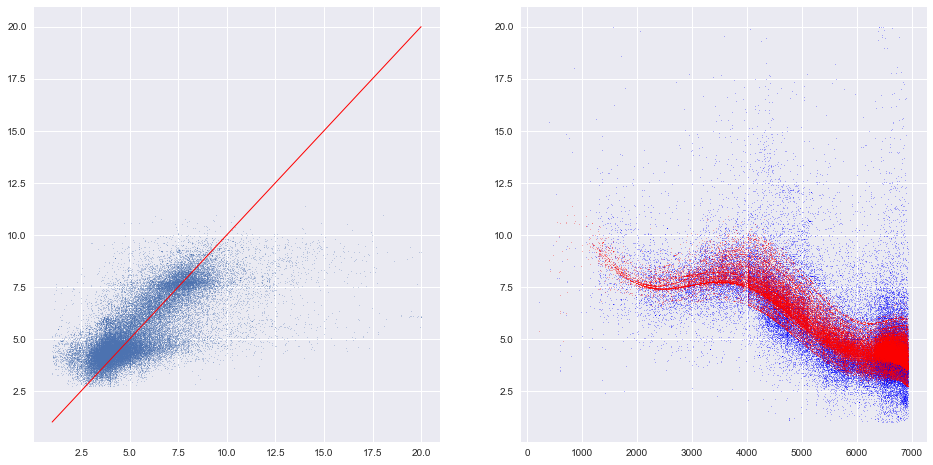

In [84]:
# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(r2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
ax1.scatter(y_test, model.predict(X_test), marker='.', s=2, alpha=0.3);
ax1.plot(np.array([1,20]), np.array([1,20]), linewidth=1, color='red')

ax2.scatter(X_test.iloc[:, 0], y_test, marker='.', color='blue', s=2, alpha=0.3)
ax2.scatter(X_test.iloc[:, 0], model.predict(X_test), marker='.', color='red', s=2, alpha=0.3)
plt.show();

In [129]:
def trainVsTestResults(results):
    ''' Plot test/train results for R^2 and RMSE'''
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    sTitle = 'mean train/test RMSE and R^2 vs poly degree'
    fig.suptitle(sTitle)
          
    mean_train_RMSE = results['mean_train_RMSE']
    mean_test_RMSE = results['mean_test_RMSE']
    n = len(mean_train_RMSE)
        
    ax1.plot(np.arange(1, n + 1), np.abs(mean_train_RMSE), marker='d', alpha=1, color='green', label='train');
    ax1.plot(np.arange(1, n + 1), np.abs(mean_test_RMSE), marker='*', alpha=0.5, color='red', label='test');
    ax1.set_ylabel('RMSE')
    ax1.set_xlabel('polynomial degree')
    ax1.set_title('mean train/test RMSE vs poly degree')

    mean_train_R2 = results['mean_train_Rsquared']
    mean_test_R2 = results['mean_test_Rsquared']
    n = len(mean_train_R2)
    
    fig.suptitle(sTitle.format(gs_cv.best_params_['features__num_vars__poly__degree']))

    ax2.plot(np.arange(1, n + 1), np.abs(mean_train_R2), marker='d', alpha=1, color='green', label='train');
    ax2.plot(np.arange(1, n + 1), np.abs(mean_test_R2), marker='*', ms=5, alpha=0.5, color='red', label='test');
    ax2.set_ylabel('R^2')
    ax2.set_xlabel('polynomial degree')
    ax2.set_title('mean train/test R2 vs poly degree')
          
    r2 = gs_cv.score(X_test, y_test)
    print("Best parameters: {}".format(gs_cv.best_params_))
    print("Best R squared: {}".format(r2))

Best parameters: {'features__num_vars__poly__degree': 11}
Best R squared: 0.5349152901661559


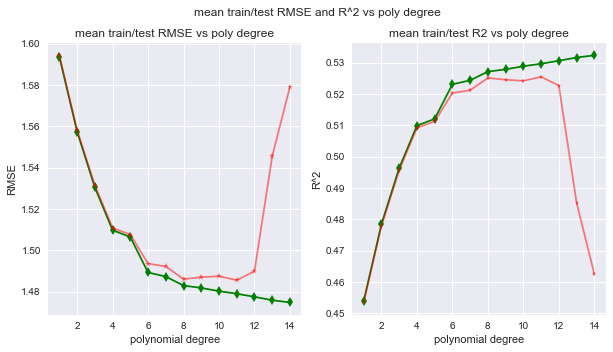

In [130]:
trainVsTestResults(gs_cv.cv_results_)

In [44]:
gs_cv.cv_results_

{'mean_fit_time': array([0.1972]),
 'mean_score_time': array([0.0401]),
 'mean_test_score': array([0.525]),
 'mean_train_score': array([0.5262]),
 'param_features__num_vars__poly__degree': masked_array(data=[6],
              mask=[False],
        fill_value='?',
             dtype=object),
 'params': [{'features__num_vars__poly__degree': 6}],
 'rank_test_score': array([1]),
 'split0_test_score': array([0.5214]),
 'split0_train_score': array([0.5281]),
 'split1_test_score': array([0.5267]),
 'split1_train_score': array([0.5253]),
 'split2_test_score': array([0.527]),
 'split2_train_score': array([0.5252]),
 'std_fit_time': array([0.0086]),
 'std_score_time': array([0.0008]),
 'std_test_score': array([0.0026]),
 'std_train_score': array([0.0013])}

In [45]:
X33p.shape, y33p.shape

((121283, 20), (121283, 1))

### Plot validation curve and learning curve

In [102]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import validation_curve

# X, y = (X33p, y33p)

param_range = np.arange(1, 15)
train_scores, test_scores = validation_curve(
    thePipe, X, y, param_name='features__num_vars__poly__degree', param_range=param_range,
    cv=3, n_jobs=1)
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

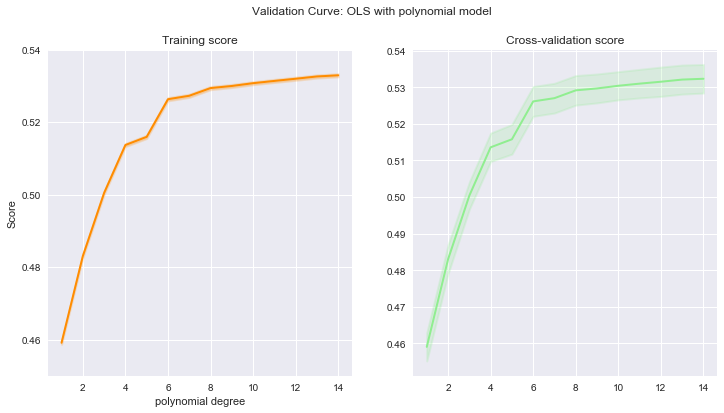

In [103]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

fig.suptitle("Validation Curve: OLS with polynomial model")
ax1.set_xlabel("polynomial degree")
ax1.set_ylabel("Score")
ax1.set_ylim(0.45, 0.54)
lw = 2
ax1.set_title("Training score")
ax1.plot(param_range, train_scores_mean, color="darkorange", lw=lw)
ax1.fill_between(param_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2,
                 color="darkorange", lw=lw)
ax2.set_title("Cross-validation score")
ax2.plot(param_range, test_scores_mean, color="lightgreen", lw=lw)
ax2.fill_between(param_range, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.2,
                 color="lightgreen", lw=lw)
plt.show()

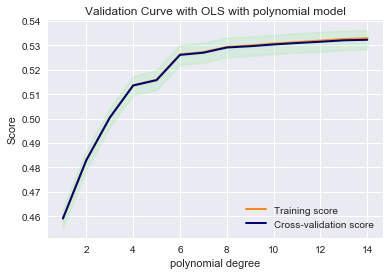

In [104]:
#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
plt.title("Validation Curve with OLS with polynomial model")
plt.xlabel("polynomial degree")
plt.ylabel("Score")
#ax1.set_ylim(0.45, 0.54)
lw = 2
# plt.set_title("Training score")
plt.plot(param_range, train_scores_mean, color="darkorange", lw=lw, label="Training score")
plt.fill_between(param_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2,
                 color="lightgreen", lw=lw)

# ax2.set_title("Cross-validation score")
plt.plot(param_range, test_scores_mean, color="navy", lw=lw, label='Cross-validation score')
plt.fill_between(param_range, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.2,
                 color="lightgreen", lw=lw)
plt.legend()
plt.show()

In [49]:
scores = pd.DataFrame(data=[train_scores_mean, test_scores_mean]).T 
scores.columns=['mean train score', 'mean test score']
scores.index = np.arange(1, 11)
scores.index.name = 'polynomial degree'
scores             

,mean train score,mean test score
polynomial degree,,
1,0.458362,0.458234
2,0.482186,0.482008
3,0.500282,0.500049
4,0.513720,0.513406
5,0.516045,0.515490
6,0.526544,0.525909
7,0.527563,0.526770
8,0.530020,0.529130
9,0.530624,0.529510


In [131]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit


def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=1, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate a simple plot of the test and training learning curve.
    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.
    title : string
        Title for the chart.
    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.
    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.
    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.
    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - An object to be used as a cross-validation generator.
          - An iterable yielding train/test splits.
        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.
        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.
    n_jobs : integer, optional
        Number of jobs to run in parallel (default 1).
    """
    plt.figure(figsize=(8, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt




In [135]:
estimator = thePipe
estimator.set_params(features__num_vars__poly__degree=2)

Pipeline(memory=None,
     steps=[('features', FeatureUnion(n_jobs=1,
       transformer_list=[('num_vars', Pipeline(memory=None,
     steps=[('extract', ColumnExtractor(columns=['num_days', 'size_kw'])), ('scale', StandardScaler(copy=True, with_mean=True, with_std=True)), ('poly', PolynomialFeatures(degree=2, include_bias=Tr...eights=None)), ('LR', LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False))])

<module 'matplotlib.pyplot' from 'C:\\Users\\saus\\Anaconda3\\lib\\site-packages\\matplotlib\\pyplot.py'>

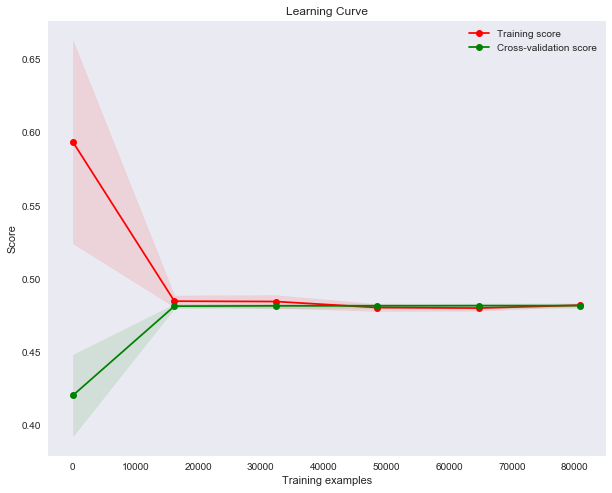

In [142]:
plot_learning_curve(estimator, 'Learning Curve', X33p, y33p, 
                    train_sizes=np.linspace(.001, 1.0, 6, endpoint=True), cv=None, n_jobs=1)

In [138]:
X33p.shape

(121283, 20)

polynomial degree: 1
polynomial degree: 2
polynomial degree: 3
polynomial degree: 4
polynomial degree: 5
polynomial degree: 6
polynomial degree: 7
polynomial degree: 8
polynomial degree: 9
polynomial degree: 10
polynomial degree: 11
polynomial degree: 12
polynomial degree: 13
polynomial degree: 14
polynomial degree: 15
polynomial degree: 16
polynomial degree: 17
polynomial degree: 18
polynomial degree: 19
polynomial degree: 20


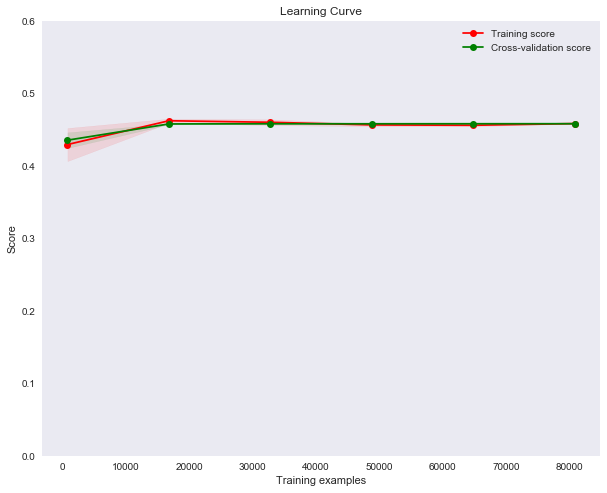

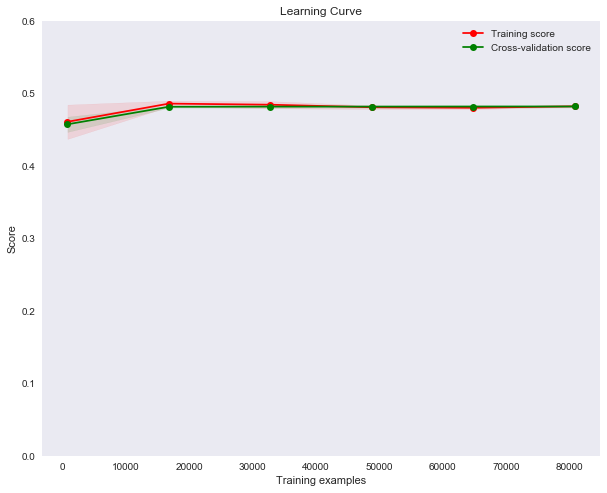

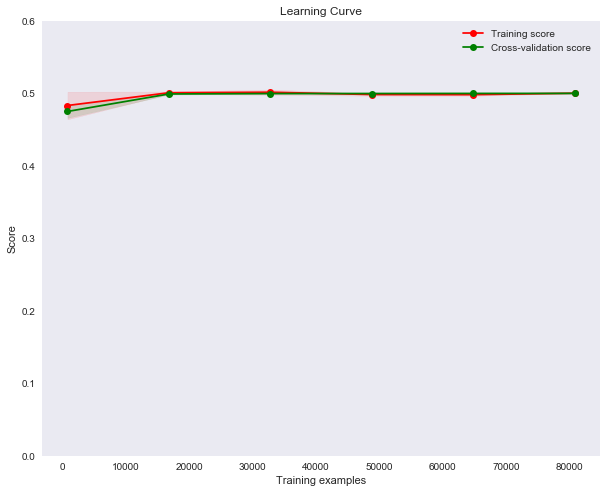

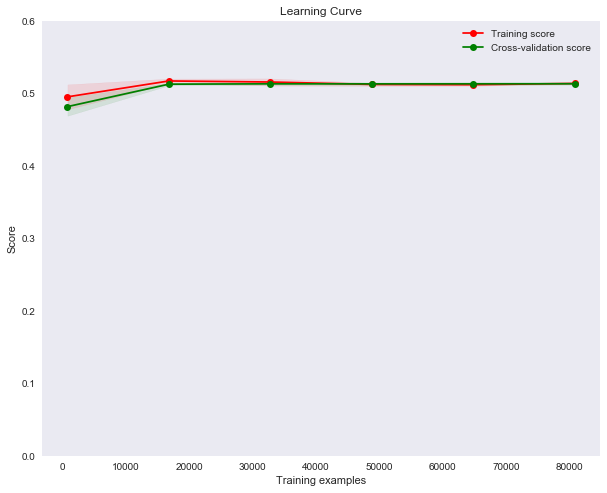

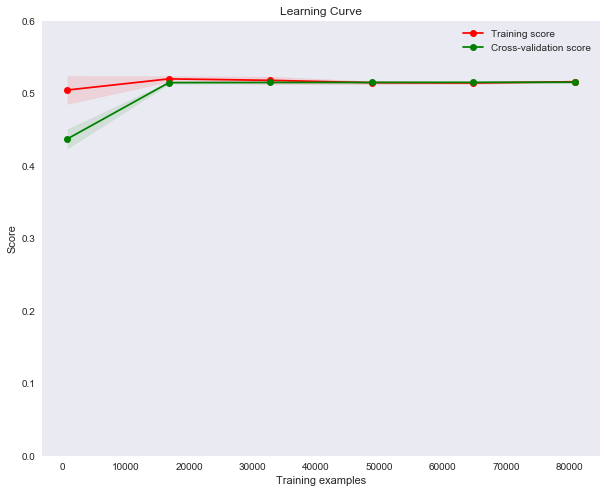

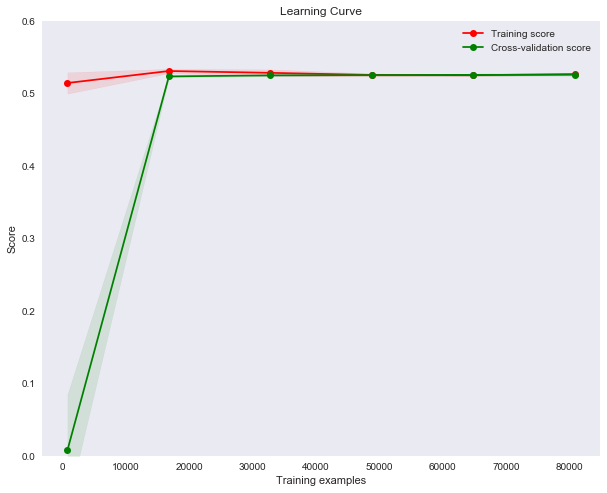

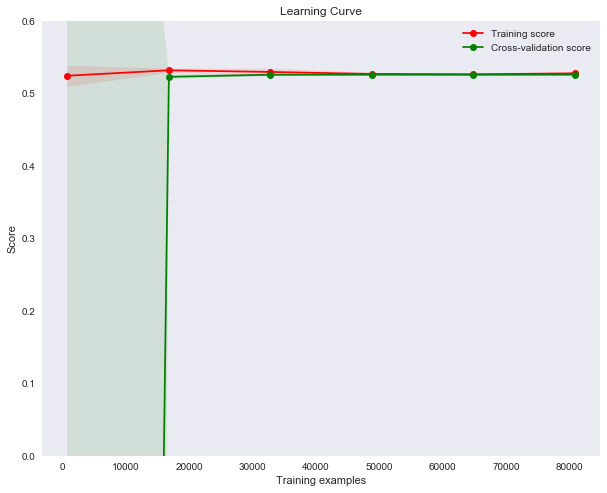

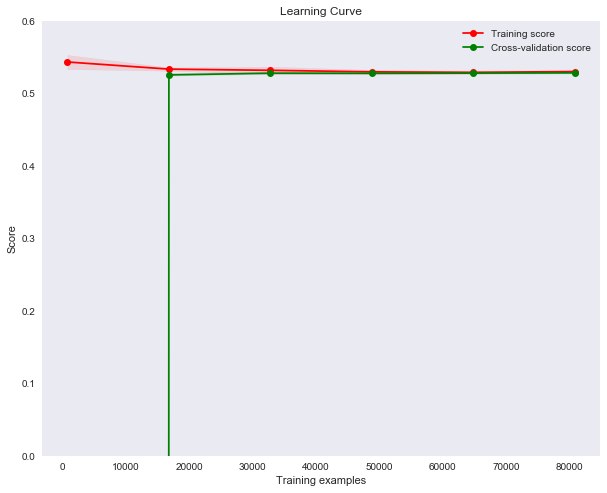

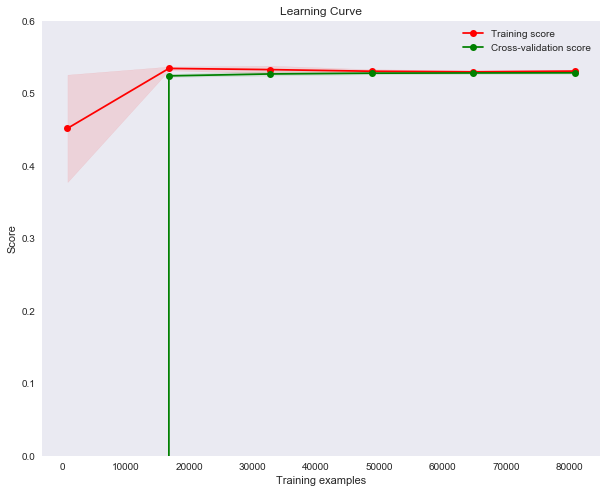

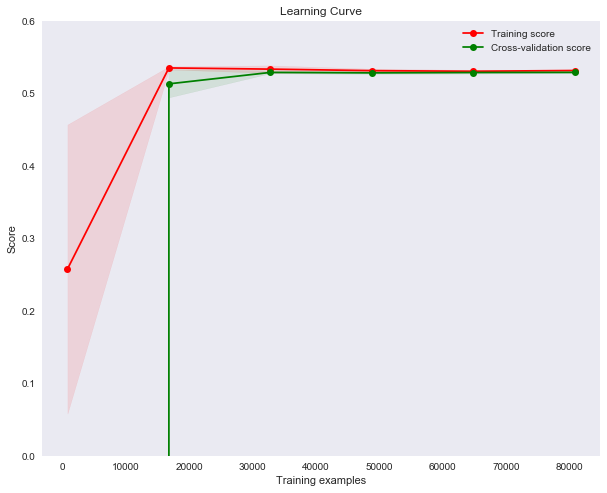

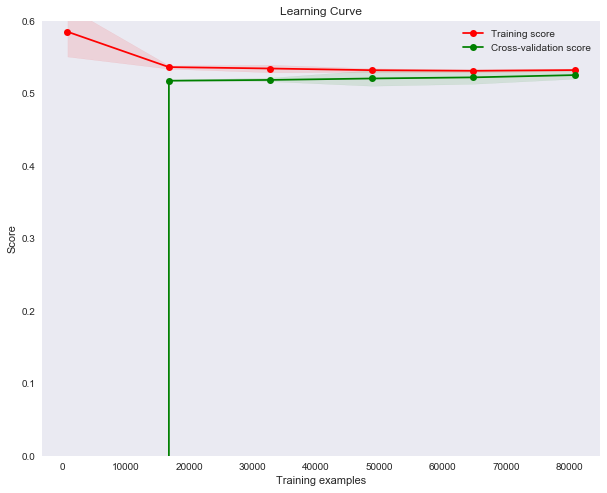

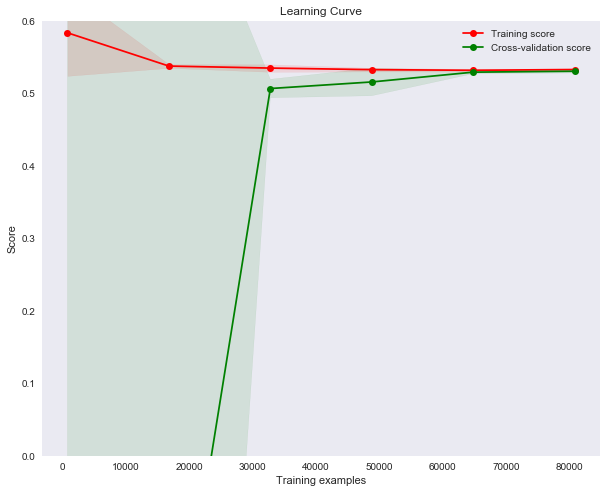

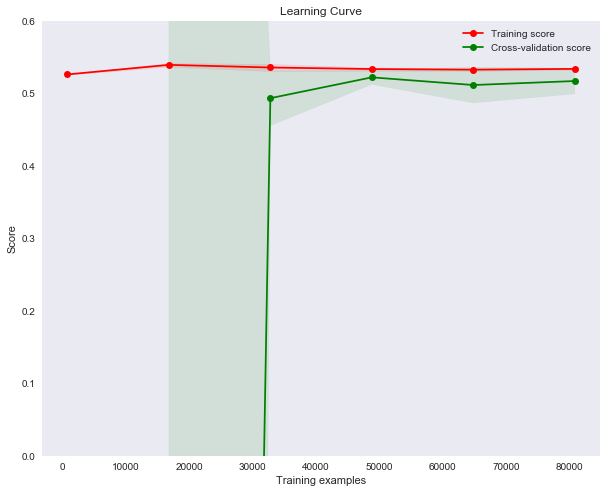

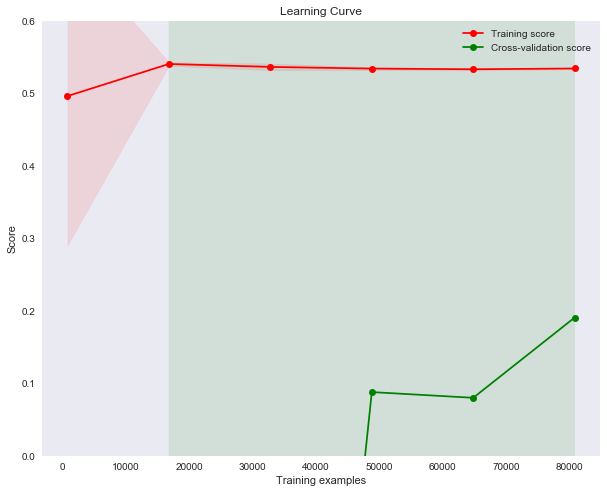

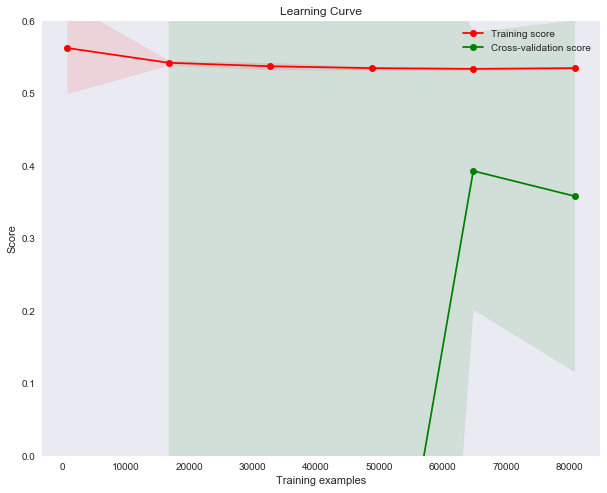

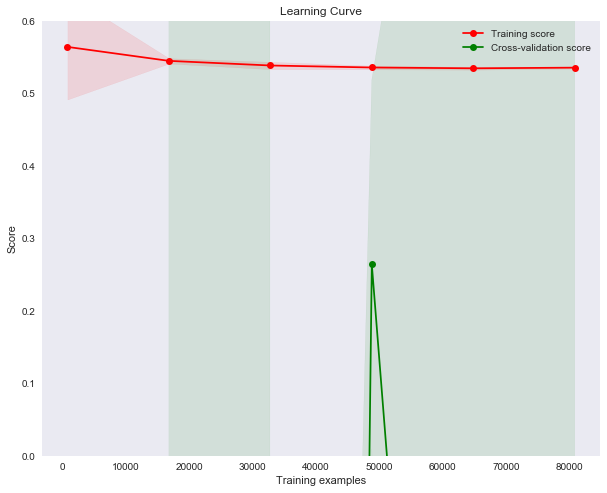

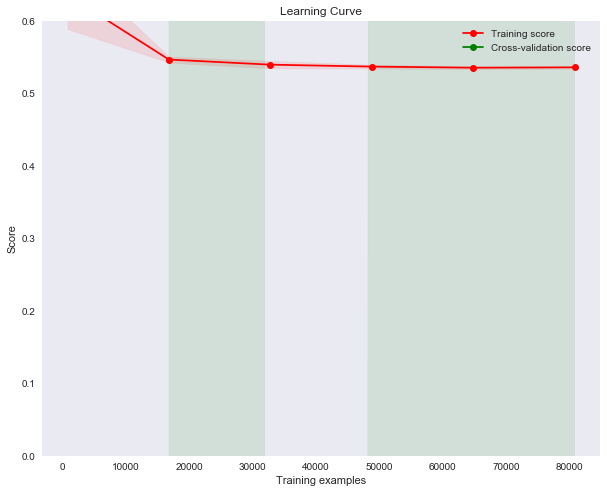

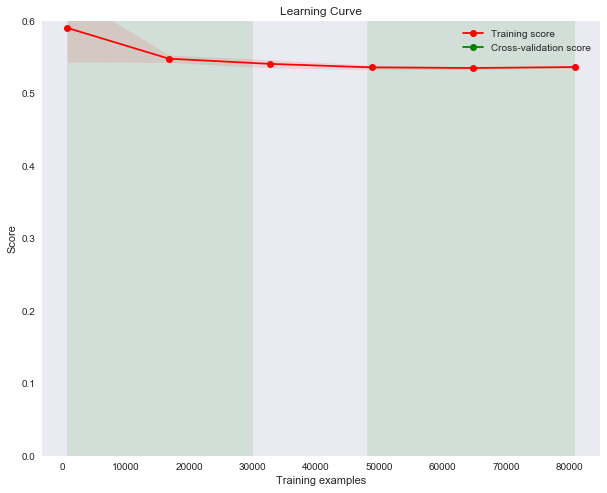

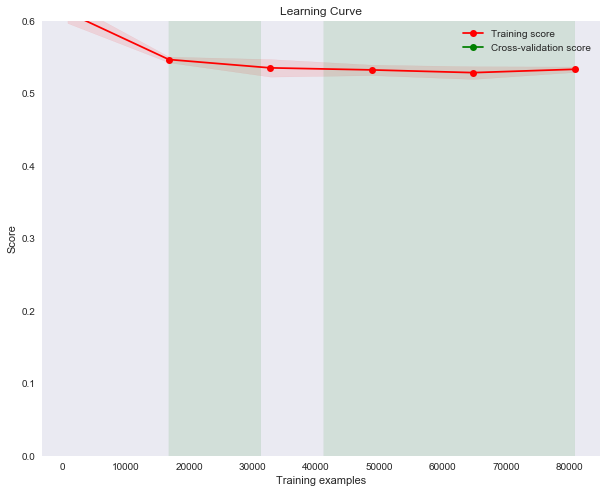

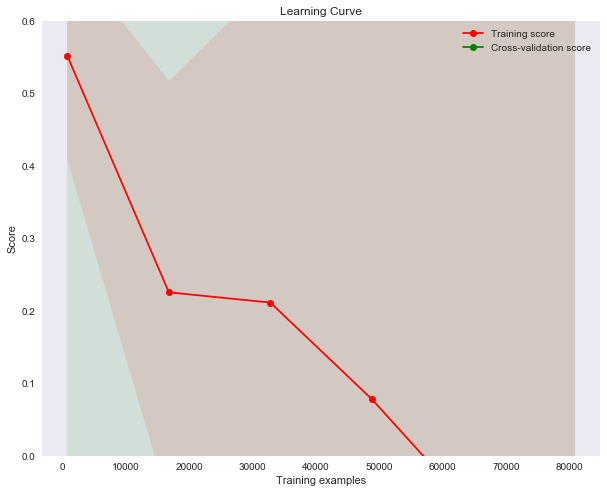

In [149]:
estimator = thePipe
for i in range(1, 21):
    estimator.set_params(features__num_vars__poly__degree=i)
   
    plot_learning_curve(estimator, 'Learning Curve', X33p, y33p, ylim=(0.0, .60),
                        train_sizes=np.linspace(.01, 1.0, 6), cv=None, n_jobs=1)
    print('polynomial degree: ' + str(i))